# Tutorial 7: Spatial LDA (Topic Modeling)

**Duration:** 25-30 minutes

This tutorial covers Spatial Latent Dirichlet Allocation (LDA), a powerful technique for discovering recurrent cellular neighborhood patterns in tissue samples.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Understand the concept of spatial topics as microenvironment signatures
- Fit Spatial LDA models to tissue data
- Interpret topic compositions and cell type associations
- Visualize topics spatially
- Evaluate model quality and select optimal number of topics

## Prerequisites

- Tutorials 1-6 completed (especially neighborhoods)
- Basic understanding of probabilistic topic models

## Biological Context

**What is Spatial LDA?**

Spatial LDA adapts text analysis techniques to discover tissue microenvironments:
- **Documents** = Cell neighborhoods
- **Words** = Cell types in the neighborhood
- **Topics** = Recurrent neighborhood patterns (microenvironment signatures)

**Applications:**
- Discovering tumor microenvironment phenotypes ("immune hot", "immune cold", "stromal barrier")
- Identifying tissue niches (stem cell, proliferative, immune)
- Comparing samples by topic prevalence
- Feature extraction for patient stratification

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialtissuepy import SpatialTissueData
from spatialtissuepy.lda import (
    SpatialLDA,
    fit_spatial_lda,
    # Analysis
    topic_cell_type_matrix,
    topic_enrichment,
    dominant_topic_per_cell,
    topic_assignment_uncertainty,
    topic_spatial_distribution,
    topic_prevalence_by_cell_type,
    topic_transition_matrix,
    # Metrics
    topic_coherence,
    topic_diversity,
    compute_model_selection_metrics,
)
from spatialtissuepy.viz import (
    plot_spatial_scatter,
    plot_topic_composition,
    plot_topic_spatial,
    plot_topic_enrichment_heatmap,
    plot_lda_diagnostics,
)

np.random.seed(42)

### Create synthetic tissue with distinct microenvironments

We'll create a tissue with three distinct regions:
1. **Tumor core:** Dense tumor with few immune cells
2. **Immune margin:** Mixture of tumor and infiltrating immune cells
3. **Stromal region:** Fibroblasts and scattered macrophages

In [2]:
# Region 1: Tumor core (center)
tumor_core = np.random.normal(loc=[500, 500], scale=60, size=(150, 2))
tumor_core_types = ['Tumor'] * 150

# Region 2: Immune margin (ring around tumor)
theta = np.random.uniform(0, 2*np.pi, 100)
r = np.random.normal(150, 30, 100)
immune_margin = np.column_stack([500 + r*np.cos(theta), 500 + r*np.sin(theta)])
immune_margin += np.random.normal(0, 15, (100, 2))
# Mix of cell types at margin
immune_types = np.random.choice(['Tumor', 'CD8_T_cell', 'CD4_T_cell', 'Macrophage'], 
                                 size=100, p=[0.3, 0.35, 0.2, 0.15])

# Region 3: Stromal region (periphery)
stromal_region = np.random.uniform(0, 1000, size=(100, 2))
# Filter to keep cells away from center
dist_from_center = np.linalg.norm(stromal_region - [500, 500], axis=1)
stromal_region = stromal_region[dist_from_center > 250]
stromal_types = np.random.choice(['Fibroblast', 'Macrophage', 'Endothelial'], 
                                  size=len(stromal_region), p=[0.5, 0.3, 0.2])

# Combine all
coordinates = np.vstack([tumor_core, immune_margin, stromal_region])
cell_types = np.concatenate([tumor_core_types, immune_types, stromal_types])

tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)
print(tissue)
print(f"\nCell types: {list(tissue.cell_types_unique)}")

SpatialTissueData
  Cells: 337
  Dimensions: 2D
  Cell types: 6
  Bounds: x=[6.4, 997.9], y=[17.9, 987.7]

Cell types: [np.str_('CD4_T_cell'), np.str_('CD8_T_cell'), np.str_('Endothelial'), np.str_('Fibroblast'), np.str_('Macrophage'), np.str_('Tumor')]


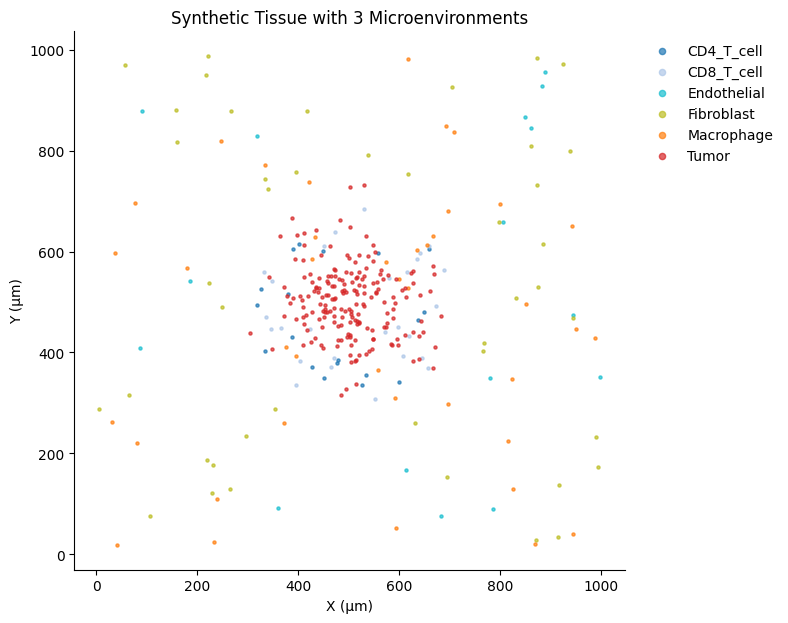

In [3]:
# Visualize the tissue
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Synthetic Tissue with 3 Microenvironments')
plt.tight_layout()
plt.show()

## Section 1: Fitting Spatial LDA

### 1.1 Quick Fit with Default Parameters

In [4]:
# Fit Spatial LDA with 4 topics
model = fit_spatial_lda(
    tissue,
    n_topics=4,
    neighborhood_radius=50.0,  # Define neighborhood size
    random_state=42
)

print(f"Model fitted with {model.n_topics} topics")
print(f"Neighborhood radius: {model.neighborhood_radius} μm")

Model fitted with 4 topics
Neighborhood radius: 50.0 μm


### 1.2 Examining Topic Compositions

Each topic is a distribution over cell types - the "signature" of a microenvironment.

In [6]:
# Get topic-cell type matrix
topic_matrix = topic_cell_type_matrix(model)

print("Topic Compositions (probability of each cell type in topic):")
print(topic_matrix.round(3))

Topic Compositions (probability of each cell type in topic):
         CD4_T_cell  CD8_T_cell  Endothelial  Fibroblast  Macrophage  Tumor
Topic_0       0.304       0.445        0.000       0.000       0.202  0.048
Topic_1       0.000       0.000        0.000       0.000       0.000  1.000
Topic_2       0.002       0.002        0.002       0.575       0.418  0.002
Topic_3       0.008       0.008        0.959       0.008       0.008  0.008


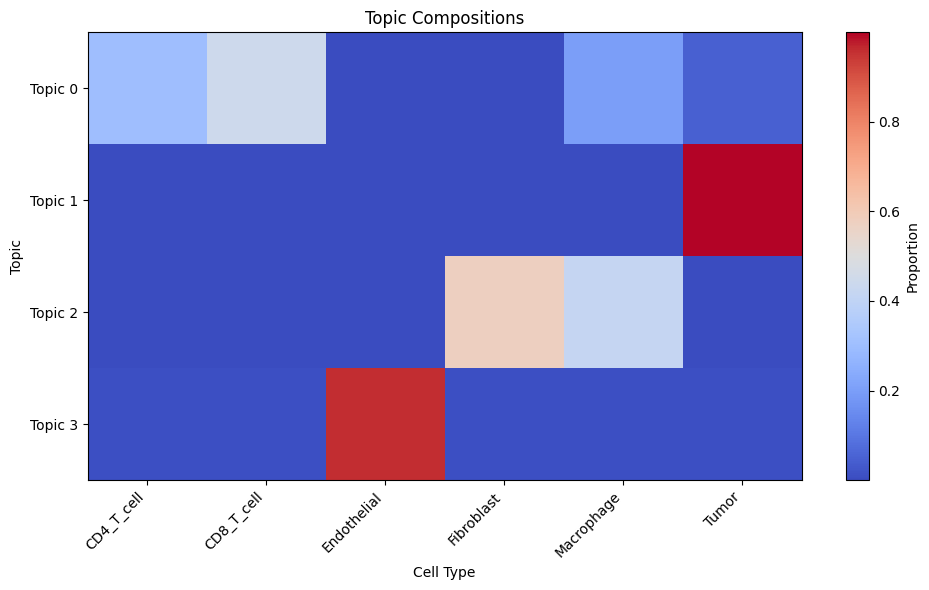


Topic Interpretations:
  Topic 0: CD8_T_cell (44%), CD4_T_cell (30%), Macrophage (20%)
  Topic 1: Tumor (100%), CD8_T_cell (0%), CD4_T_cell (0%)
  Topic 2: Fibroblast (57%), Macrophage (42%), Endothelial (0%)
  Topic 3: Endothelial (96%), Fibroblast (1%), Macrophage (1%)


In [7]:
# Visualize topic compositions
fig, ax = plt.subplots(figsize=(10, 6))
plot_topic_composition(model, ax=ax, cmap='coolwarm')
ax.set_title('Topic Compositions')
plt.tight_layout()
plt.show()

# Interpret each topic
print("\nTopic Interpretations:")
for i in range(model.n_topics):
    top_types = topic_matrix.iloc[i].nlargest(3)
    interpretation = ", ".join([f"{ct} ({p:.0%})" for ct, p in top_types.items()])
    print(f"  Topic {i}: {interpretation}")

## Section 2: Topic Assignments

### 2.1 Assigning Topics to Cells

In [8]:
# Get topic weights for each cell
topic_weights = model.transform(tissue)

print(f"Topic weights shape: {topic_weights.shape}")
print(f"Each row sums to: {topic_weights[0].sum():.4f}")
print(f"\nExample (cell 0): {topic_weights[0].round(3)}")

Topic weights shape: (337, 4)
Each row sums to: 1.0000

Example (cell 0): [0.007 0.979 0.007 0.007]


In [9]:
# Get dominant topic for each cell
dominant_topics = dominant_topic_per_cell(model, tissue)

print("Dominant Topic Distribution:")
for i in range(model.n_topics):
    count = np.sum(dominant_topics == i)
    pct = 100 * count / len(dominant_topics)
    print(f"  Topic {i}: {count} cells ({pct:.1f}%)")

Dominant Topic Distribution:
  Topic 0: 35 cells (10.4%)
  Topic 1: 215 cells (63.8%)
  Topic 2: 68 cells (20.2%)
  Topic 3: 19 cells (5.6%)


In [10]:
# Assignment uncertainty (entropy)
uncertainty = topic_assignment_uncertainty(model, tissue)

print(f"\nAssignment Uncertainty:")
print(f"  Mean: {uncertainty.mean():.3f}")
print(f"  Low uncertainty = confident assignment")
print(f"  High uncertainty = ambiguous (mixed) assignment")


Assignment Uncertainty:
  Mean: 0.908
  Low uncertainty = confident assignment
  High uncertainty = ambiguous (mixed) assignment


### 2.2 Visualizing Topics Spatially

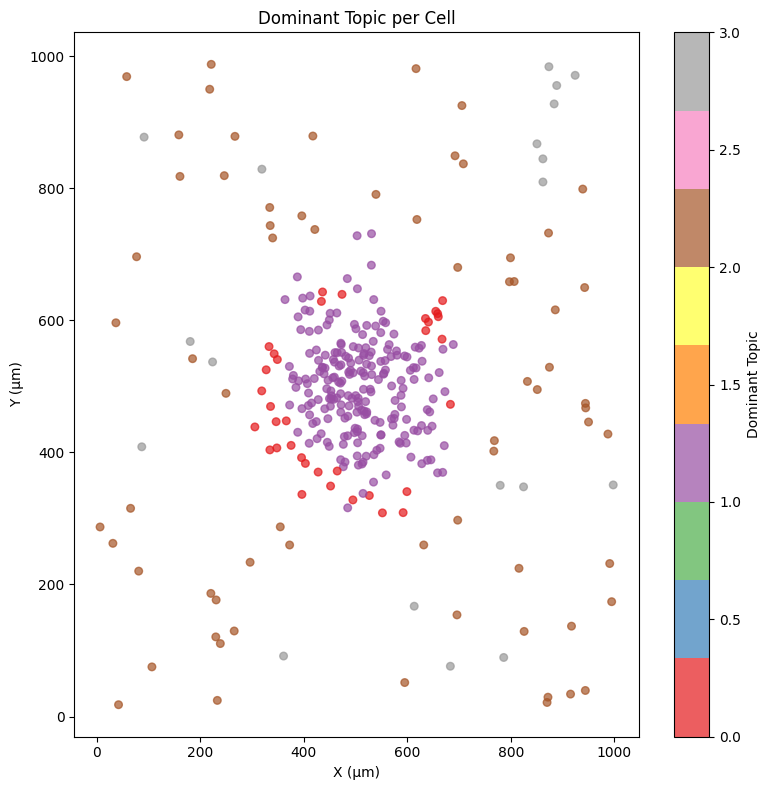

In [11]:
# This needs to be done better. Change the colorbar to a discrete legend or use boundary norms

# Plot dominant topic assignments
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    tissue.coordinates[:, 0],
    tissue.coordinates[:, 1],
    c=dominant_topics,
    cmap='Set1',
    s=30,
    alpha=0.7
)
plt.colorbar(scatter, ax=ax, label='Dominant Topic')
ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title('Dominant Topic per Cell')
plt.tight_layout()
plt.show()

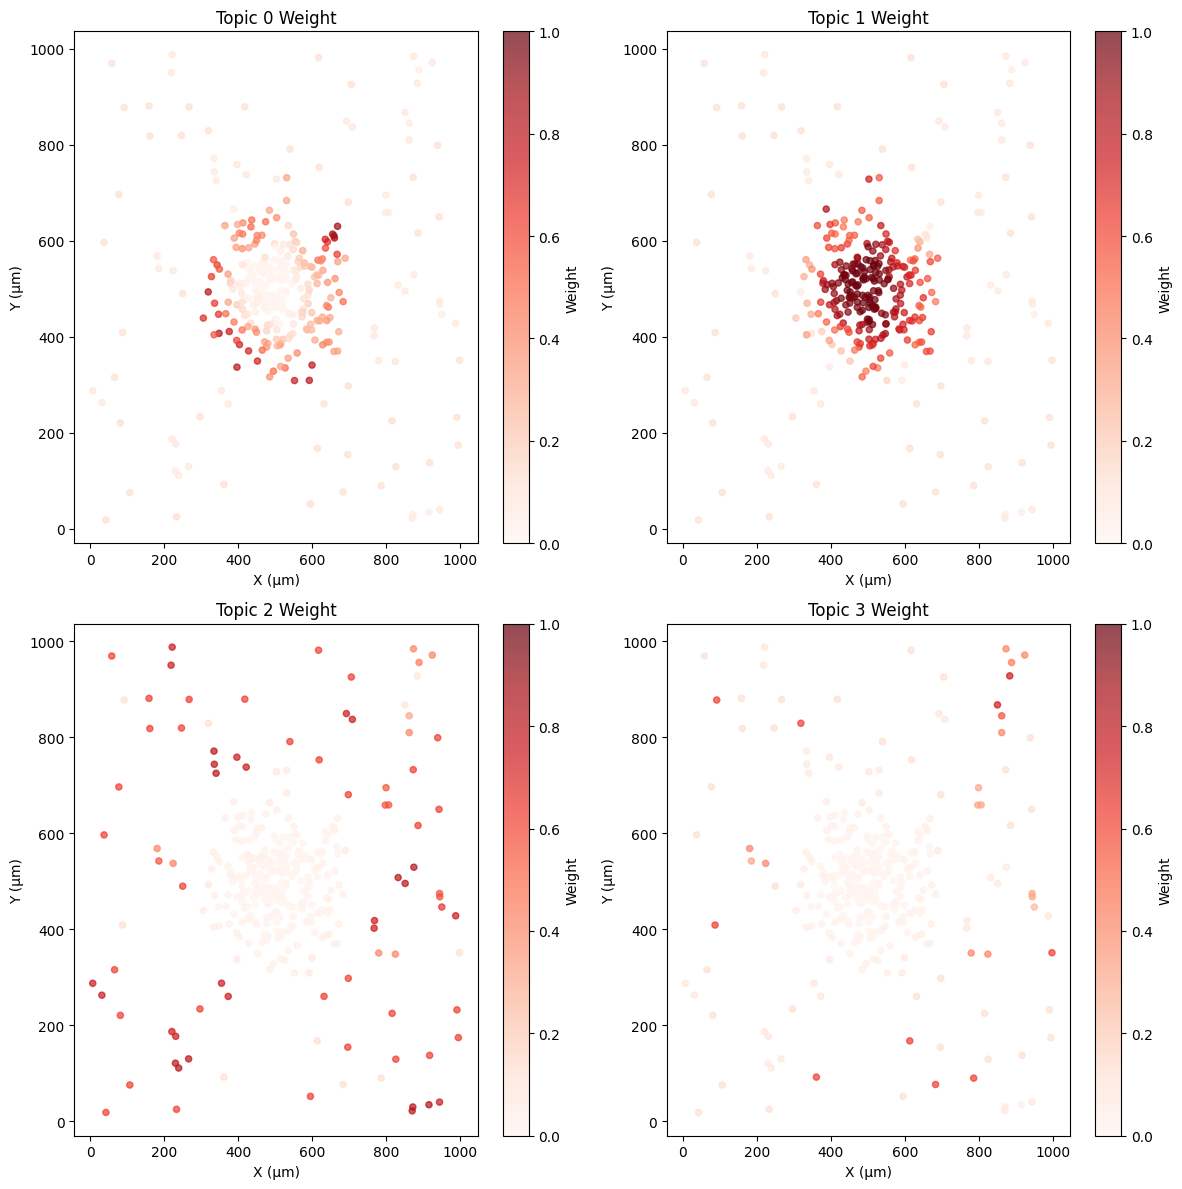

In [12]:
# Plot individual topic weights
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    if i < model.n_topics:
        scatter = ax.scatter(
            tissue.coordinates[:, 0],
            tissue.coordinates[:, 1],
            c=topic_weights[:, i],
            cmap='Reds',
            vmin=0, vmax=1,
            s=20,
            alpha=0.7
        )
        plt.colorbar(scatter, ax=ax, label='Weight')
        ax.set_title(f'Topic {i} Weight')
        ax.set_xlabel('X (μm)')
        ax.set_ylabel('Y (μm)')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

## Section 3: Topic Analysis

### 3.1 Topic Enrichment by Cell Type

In [14]:
# Which topics are associated with which cell types?
enrichment = topic_enrichment(model)

print("Topic Enrichment by Cell Type:")
print("(Mean topic weight for cells of each type)")
print(enrichment.round(3))

Topic Enrichment by Cell Type:
(Mean topic weight for cells of each type)
         CD4_T_cell  CD8_T_cell  Endothelial  Fibroblast  Macrophage  Tumor
Topic_0       0.866       1.416       -8.779      -8.779       0.279 -1.788
Topic_1     -11.629     -11.610      -11.671     -11.671     -11.629  2.585
Topic_2      -6.483      -6.483       -6.467       1.786       1.326 -6.480
Topic_3      -4.385      -4.385        2.525      -4.327      -4.335 -4.383


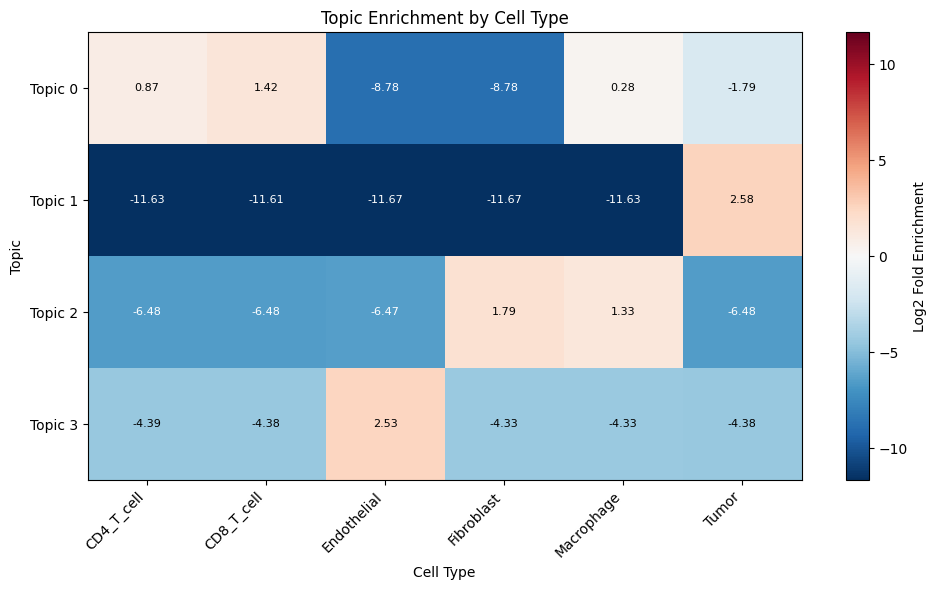

In [15]:
# Visualize enrichment
fig, ax = plt.subplots(figsize=(10, 6))
plot_topic_enrichment_heatmap(model, ax=ax)
ax.set_title('Topic Enrichment by Cell Type')
plt.tight_layout()
plt.show()

### 3.2 Topic Prevalence by Cell Type

In [16]:
# What's the dominant topic for each cell type?
prevalence = topic_prevalence_by_cell_type(model, tissue)

print("Topic Prevalence (% of cells with each dominant topic):")
#for r, row in prevalence.iterrows():
#    ct = row['cell_type']
#    print(f"\n{ct}:")
#    for topic, pct in enumerate(dist):
#        print(f"  Topic {topic}: {pct:.1}%")
prevalence

Topic Prevalence (% of cells with each dominant topic):


,cell_type,n_cells,topic_0_mean,topic_0_std,topic_1_mean,topic_1_std,topic_2_mean,topic_2_std,topic_3_mean,topic_3_std
0,CD4_T_cell,19,0.491083,0.210181,0.454911,0.231502,0.027562,0.015717,0.026444,0.014299
1,CD8_T_cell,27,0.469599,0.196915,0.474640,0.209793,0.028095,0.015105,0.027666,0.015205
2,Endothelial,16,0.097307,0.029041,0.096875,0.029371,0.251535,0.183921,0.554283,0.141733
3,Fibroblast,43,0.097860,0.026560,0.097578,0.026857,0.664307,0.113082,0.140256,0.102299
4,Macrophage,40,0.238710,0.247185,0.185453,0.194637,0.472083,0.304634,0.103753,0.094134
5,Tumor,192,0.141396,0.164424,0.830980,0.178649,0.014357,0.012071,0.013267,0.011117


### 3.3 Topic Transitions (Neighboring Topics)

In [17]:
# How do topics transition spatially?
transitions = topic_transition_matrix(model, tissue, radius=50.0)

print("Topic Transition Matrix:")
print("(Probability of neighbor having topic j given focal cell has topic i)")
print(transitions.round(3))

Topic Transition Matrix:
(Probability of neighbor having topic j given focal cell has topic i)
         Topic_0  Topic_1  Topic_2  Topic_3
Topic_0    0.585    0.415    0.000    0.000
Topic_1    0.019    0.981    0.000    0.000
Topic_2    0.000    0.000    0.964    0.036
Topic_3    0.000    0.000    0.143    0.857


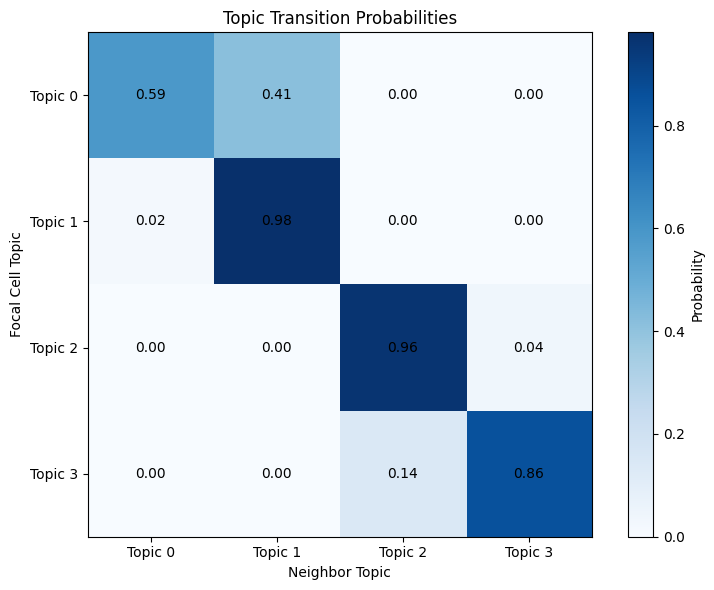


High diagonal = spatially coherent topics
High off-diagonal = topic boundaries


In [18]:
# Visualize transitions
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(transitions, cmap='Blues')
ax.set_xticks(range(model.n_topics))
ax.set_yticks(range(model.n_topics))
ax.set_xticklabels([f'Topic {i}' for i in range(model.n_topics)])
ax.set_yticklabels([f'Topic {i}' for i in range(model.n_topics)])
ax.set_xlabel('Neighbor Topic')
ax.set_ylabel('Focal Cell Topic')
ax.set_title('Topic Transition Probabilities')
plt.colorbar(im, label='Probability')

# Annotate
for i in range(model.n_topics):
    for j in range(model.n_topics):
        ax.text(j, i, f'{transitions.iloc[i,j]:.2f}', ha='center', va='center')

plt.tight_layout()
plt.show()

print("\nHigh diagonal = spatially coherent topics")
print("High off-diagonal = topic boundaries")

## Section 4: Model Quality and Selection

### 4.1 Topic Quality Metrics

In [31]:
# Compute quality metrics
coherence = topic_coherence(model, tissue)
diversity = topic_diversity(model)

print("Model Quality Metrics:")
print("  Topic coherences:") 
[print(f"     {k}:{c.round(3)}") for (k, c) in coherence.items()]
print(f"  Topic diversity: {diversity:.3f}")
print("\nInterpretation:")
print("  Coherence: Higher = topics make more semantic sense")
print("  Diversity: Higher = topics are more distinct from each other")

Model Quality Metrics:
  Topic coherences:
     0:0.158
     1:0.158
     2:0.15
     3:0.15
  Topic diversity: 0.000

Interpretation:
  Coherence: Higher = topics make more semantic sense
  Diversity: Higher = topics are more distinct from each other


### 4.2 Selecting Number of Topics

In [42]:
# Try different numbers of topics
n_topics_range = [2, 3, 4, 5, 6, 7, 8]
metrics = compute_model_selection_metrics(tissue, n_topics_range, random_state=42)

print("Model Selection Metrics:")
metrics

Model Selection Metrics:


,n_topics,perplexity,log_likelihood,diversity,mean_coherence
0,2,1.658488,-2888.218451,0.0,0.183251
1,3,1.679115,-2958.784990,0.0,0.145120
2,4,1.734341,-3143.531862,0.0,0.154105
3,5,1.759411,-3225.464470,0.0,0.158699
4,6,1.791429,-3328.425695,0.0,0.168966
5,7,1.818090,-3412.762079,0.0,0.153493
6,8,1.830543,-3451.734806,0.0,0.154029


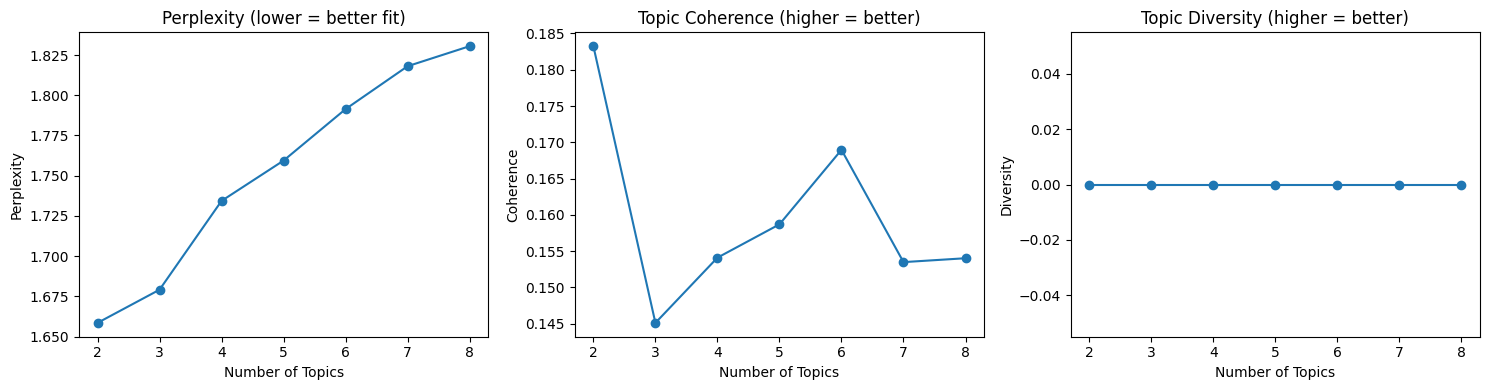


Tip: Look for elbow in perplexity curve, high coherence and diversity


In [45]:
# Plot metrics vs number of topics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(metrics['n_topics'], metrics['perplexity'], 'o-')
axes[0].set_xlabel('Number of Topics')
axes[0].set_ylabel('Perplexity')
axes[0].set_title('Perplexity (lower = better fit)')

axes[1].plot(metrics['n_topics'], metrics['mean_coherence'], 'o-')
axes[1].set_xlabel('Number of Topics')
axes[1].set_ylabel('Coherence')
axes[1].set_title('Topic Coherence (higher = better)')

axes[2].plot(metrics['n_topics'], metrics['diversity'], 'o-')
axes[2].set_xlabel('Number of Topics')
axes[2].set_ylabel('Diversity')
axes[2].set_title('Topic Diversity (higher = better)')

plt.tight_layout()
plt.show()

print("\nTip: Look for elbow in perplexity curve, high coherence and diversity")

## Section 5: Advanced Usage

### 5.1 Using the Class Interface

In [46]:
# More control with SpatialLDA class
model_custom = SpatialLDA(
    n_topics=4,
    neighborhood_method='radius',
    neighborhood_radius=60.0,
    doc_topic_prior=0.1,  # Alpha parameter (sparsity)
    topic_word_prior=0.01,  # Beta parameter
    max_iter=100,
    random_state=42
)

model_custom.fit(tissue)
print(f"Custom model fitted with perplexity: {model_custom.perplexity(tissue):.2f}")

Custom model fitted with perplexity: 1.68


### 5.2 Multi-Sample Analysis

In [47]:
# Create a second sample with different composition
np.random.seed(123)
coords2 = np.random.uniform(0, 1000, size=(300, 2))
types2 = np.random.choice(['Tumor', 'CD8_T_cell', 'Fibroblast'], size=300, p=[0.2, 0.5, 0.3])
tissue2 = SpatialTissueData(coordinates=coords2, cell_types=types2)

# Fit joint model on both samples
joint_model = SpatialLDA(n_topics=4, neighborhood_radius=50.0, random_state=42)
joint_model.fit([tissue, tissue2])

# Compare topic prevalence
topics1 = dominant_topic_per_cell(joint_model, tissue)
topics2 = dominant_topic_per_cell(joint_model, tissue2)

print("Topic Distribution Comparison:")
print("\nSample 1 (tumor with margin):")
for i in range(joint_model.n_topics):
    print(f"  Topic {i}: {100 * np.mean(topics1 == i):.1f}%")

print("\nSample 2 (immune rich):")
for i in range(joint_model.n_topics):
    print(f"  Topic {i}: {100 * np.mean(topics2 == i):.1f}%")

Topic Distribution Comparison:

Sample 1 (tumor with margin):
  Topic 0: 12.8%
  Topic 1: 65.9%
  Topic 2: 0.3%
  Topic 3: 21.1%

Sample 2 (immune rich):
  Topic 0: 0.0%
  Topic 1: 15.3%
  Topic 2: 77.3%
  Topic 3: 7.3%


## Exercise: Interpret Your Topics

1. **Biological naming:** Give biological names to each discovered topic based on their cell type compositions (e.g., "Tumor Core", "Immune Margin", "Stromal Niche").

2. **Marker integration:** If marker data is available, compute mean marker expression for cells in each topic.

3. **Topic-based feature extraction:** Extract topic proportions as features for downstream ML (e.g., predicting treatment response).

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **Spatial LDA concept:** Topics as recurrent microenvironment signatures
- **Model fitting:** Using `fit_spatial_lda()` and the `SpatialLDA` class
- **Topic interpretation:** Understanding topic compositions and cell type associations
- **Spatial visualization:** Mapping topics back onto tissue
- **Model selection:** Using coherence, diversity, and perplexity to choose n_topics

**Key insights:**
- Topics capture recurrent neighborhood patterns
- Topic enrichment reveals which cell types drive each microenvironment
- Topic proportions serve as tissue-level features for ML
- Joint fitting enables cross-sample comparison

## Next Steps

- **Tutorial 8: Topology/Mapper** - Alternative approach to community discovery
- **Tutorial 10: Multi-Sample Analysis** - Comparing samples using topic features